# Modèle de Prévision de la Demande

---

## Objectif de ce notebook

Prédire les **sorties journalières** (consommation) du Gasoil au Dépôt Central Lomé  
pour les 30 prochains jours, afin d'anticiper les besoins en réapprovisionnement.  

**Choix du couple dépôt/produit :** Gasoil (PRD003) + Dépôt Central Lomé (D001)  
Ce couple est le plus représentatif du dataset (dépôt le plus actif, produit stratégique).  
La méthodologie présentée ici est généralisable à toutes les combinaisons dépôt/produit.

**Algorithmes comparés :** Prophet (Facebook/Meta) vs ARIMA  
**Métriques d'évaluation :** MAE, RMSE, MAPE  
**Séparation train/test :** 2015–2022 (entraînement) / 2023–2024 (test) — ordre chronologique respecté

---

## 0. Imports et Configuration

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Dossiers racine pour les figures et modèles
FIGURES_DIR = os.path.join('../figures')
MODELS_DIR = os.path.join('../models')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

_original_savefig = plt.savefig
def savefig_root(path, *args, **kwargs):
    if isinstance(path, str) and path.startswith('figures/'):
        path = os.path.join('..', path)
    return _original_savefig(path, *args, **kwargs)

plt.savefig = savefig_root

print('Imports OK ✅')

Imports OK ✅


## 1. Chargement et Sélection des Données

On extrait la série temporelle du couple Gasoil / Dépôt Central Lomé.

In [23]:
df_full = pd.read_csv('../data/stocks_journaliers.csv')
df_full['date'] = pd.to_datetime(df_full['date'])

# Sélection du couple représentatif
PRODUIT_ID = 'PRD003'  # Gasoil
DEPOT_ID   = 'D001'   # Dépôt Central Lomé

df = df_full[
    (df_full['produit_id'] == PRODUIT_ID) &
    (df_full['depot_id'] == DEPOT_ID)
].copy().sort_values('date').reset_index(drop=True)

print(f"Série : Gasoil — Dépôt Central Lomé")
print(f"Lignes    : {len(df):,}")
print(f"Période   : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Sorties   : moyenne={df['sorties'].mean():.1f}, std={df['sorties'].std():.1f}")
print(f"            min={df['sorties'].min():.1f}, max={df['sorties'].max():.1f}")
df[['date', 'sorties', 'stock_fin_jour', 'prix_wti_usd_baril']].head()

Série : Gasoil — Dépôt Central Lomé
Lignes    : 3,653
Période   : 2015-01-01 → 2024-12-31
Sorties   : moyenne=778.8, std=210.6
            min=106.8, max=1311.3


,date,sorties,stock_fin_jour,prix_wti_usd_baril
0,2015-01-01,889.43,67173.87,55.00
1,2015-01-02,1025.25,66148.62,55.60
2,2015-01-03,468.64,65679.98,55.44
3,2015-01-04,469.90,65210.09,56.22
4,2015-01-05,937.43,73975.82,58.06


## 2. Feature Engineering

On enrichit la série avec des variables temporelles, des moyennes glissantes (lissage de la consommation)  
et des lag features (valeurs passées). Ces variables améliorent la capacité prédictive des modèles.

In [24]:
# ── Variables temporelles ──────────────────────────────────────────────────────
df['jour_semaine']  = df['date'].dt.dayofweek          # 0=Lundi, 6=Dimanche
df['mois']          = df['date'].dt.month
df['trimestre']     = df['date'].dt.quarter
df['annee']         = df['date'].dt.year
df['is_weekend']    = (df['date'].dt.dayofweek >= 5).astype(int)
df['jour_annee']    = df['date'].dt.dayofyear

# ── Moyennes glissantes sur les sorties ───────────────────────────────────────
# Elles capturent la tendance locale et lissent le bruit journalier
# Horizon 7j  → tendance hebdomadaire (cycle court)
# Horizon 14j → tendance bi-mensuelle
# Horizon 30j → tendance mensuelle (cycle long, délai fournisseur)
df['sorties_ma7']  = df['sorties'].rolling(window=7,  min_periods=1).mean()
df['sorties_ma14'] = df['sorties'].rolling(window=14, min_periods=1).mean()
df['sorties_ma30'] = df['sorties'].rolling(window=30, min_periods=1).mean()

# ── Lag features (valeurs passées) ────────────────────────────────────────────
# Lag 1  → consommation d'hier (forte corrélation attendue)
# Lag 7  → même jour la semaine passée (cycle hebdomadaire)
# Lag 30 → même période le mois passé (cycle mensuel)
df['sorties_lag1']  = df['sorties'].shift(1)
df['sorties_lag7']  = df['sorties'].shift(7)
df['sorties_lag30'] = df['sorties'].shift(30)

# Supprimer les lignes avec NaN créées par les lags
df = df.dropna().reset_index(drop=True)

print(f"Dataset enrichi : {len(df):,} lignes × {len(df.columns)} colonnes")
print(f"\nNouvelles variables créées :")
nouvelles = ['jour_semaine','mois','trimestre','annee','is_weekend','jour_annee',
             'sorties_ma7','sorties_ma14','sorties_ma30',
             'sorties_lag1','sorties_lag7','sorties_lag30']
for v in nouvelles:
    print(f"  {v}")

Dataset enrichi : 3,623 lignes × 31 colonnes

Nouvelles variables créées :
  jour_semaine
  mois
  trimestre
  annee
  is_weekend
  jour_annee
  sorties_ma7
  sorties_ma14
  sorties_ma30
  sorties_lag1
  sorties_lag7
  sorties_lag30


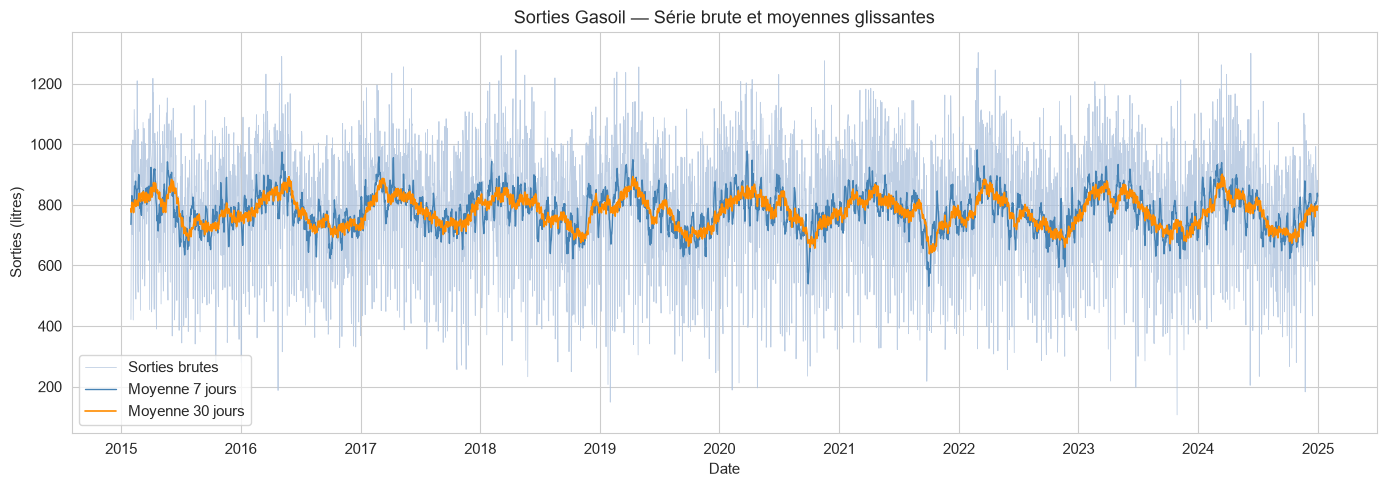

In [ ]:
# Visualisation des moyennes glissantes vs série brute
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], df['sorties'],
        color='lightsteelblue', linewidth=0.6, alpha=0.8, label='Sorties brutes')
ax.plot(df['date'], df['sorties_ma7'],
        color='steelblue', linewidth=1.0, label='Moyenne 7 jours')
ax.plot(df['date'], df['sorties_ma30'],
        color='darkorange', linewidth=1.2, label='Moyenne 30 jours')
ax.set_title('Sorties Gasoil — Série brute et moyennes glissantes')
ax.set_xlabel('Date')
ax.set_ylabel('Sorties (litres)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/01_series_et_moyennes_glissantes.png', dpi=150)
plt.show()

## 3. Séparation Train / Test

La séparation est **chronologique** — on n'utilise jamais de données futures pour entraîner.  
Ici : **2015–2022** pour l'entraînement (80%), **2023–2024** pour le test (20%).

Ce choix est justifié par les délais fournisseurs observés dans `bons_commande` :  
le délai moyen est de 8,5 jours. Un horizon de prévision de **30 jours** offre donc  
une marge confortable pour déclencher une commande avant la rupture.

Train : 2,892 observations (2015-01-31 → 2022-12-31)
Test  : 731  observations (2023-01-01 → 2024-12-31)
Ratio : 80% / 20%


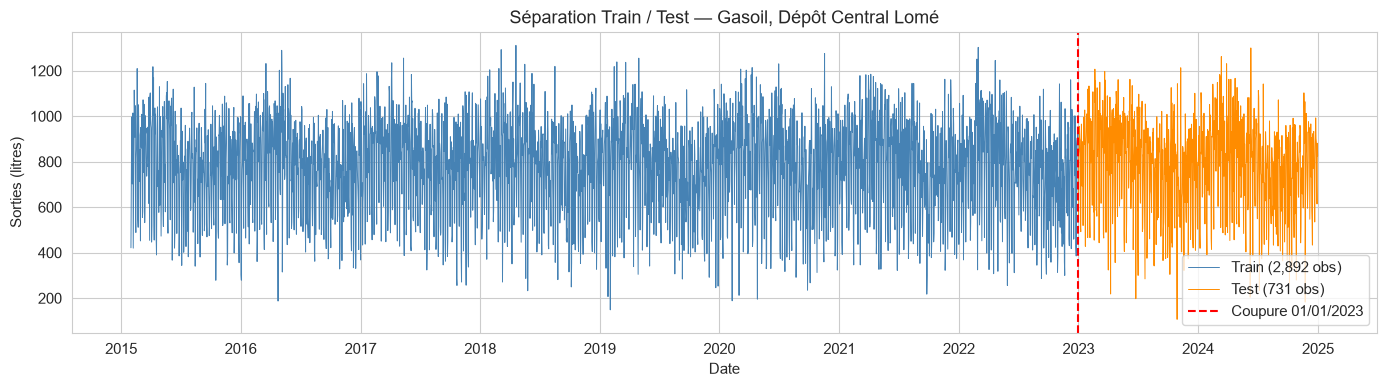

In [ ]:
CUTOFF = '2023-01-01'

train = df[df['date'] < CUTOFF].copy()
test  = df[df['date'] >= CUTOFF].copy()

print(f"Train : {len(train):,} observations ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test  : {len(test):,}  observations ({test['date'].min().date()} → {test['date'].max().date()})")
print(f"Ratio : {len(train)/len(df)*100:.0f}% / {len(test)/len(df)*100:.0f}%")

# Visualisation du split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train['date'], train['sorties'],
        color='steelblue', linewidth=0.7, label=f'Train ({len(train):,} obs)')
ax.plot(test['date'], test['sorties'],
        color='darkorange', linewidth=0.7, label=f'Test ({len(test):,} obs)')
ax.axvline(pd.to_datetime(CUTOFF), color='red',
           linestyle='--', linewidth=1.5, label='Coupure 01/01/2023')
ax.set_title('Séparation Train / Test — Gasoil, Dépôt Central Lomé')
ax.set_xlabel('Date')
ax.set_ylabel('Sorties (litres)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/02_train_test_split.png', dpi=150)
plt.show()

## 4. Test de Stationnarité (ADF)

Avant ARIMA, on vérifie si la série est stationnaire.  
Une série est stationnaire si sa moyenne et sa variance sont constantes dans le temps.  
Si elle ne l'est pas, on applique une différenciation (paramètre `d` d'ARIMA).

In [27]:
# Test ADF (Augmented Dickey-Fuller)
# H0 : la série a une racine unitaire (non stationnaire)
# Si p-value < 0.05 → on rejette H0 → la série est stationnaire
result = adfuller(train['sorties'].dropna())

print("=== Test de Dickey-Fuller Augmenté (ADF) ===")
print(f"  Statistique ADF : {result[0]:.4f}")
print(f"  p-value         : {result[1]:.6f}")
print(f"  Valeurs critiques :")
for key, val in result[4].items():
    print(f"    {key} : {val:.4f}")
print()
if result[1] < 0.05:
    print("✅ p-value < 0.05 → La série est STATIONNAIRE → d=0")
else:
    print("⚠️  p-value >= 0.05 → La série est NON STATIONNAIRE → d=1 (différenciation)")

=== Test de Dickey-Fuller Augmenté (ADF) ===
  Statistique ADF : -5.1403
  p-value         : 0.000012
  Valeurs critiques :
    1% : -3.4326
    5% : -2.8626
    10% : -2.5673

✅ p-value < 0.05 → La série est STATIONNAIRE → d=0


**📝 Observation :**

> La p-value du test ADF est très inférieure à 0,05, ce qui confirme que la série est **stationnaire** — cohérent avec la tendance quasi-nulle observée lors de l'EDA (-0,5% sur 10 ans). On posera donc **d=0** pour ARIMA. Les paramètres p et q seront fixés à **p=2, q=1** — valeurs classiques pour une série de consommation journalière avec légère autocorrélation.

## 5. Modèle 1 — Prophet

Prophet est un algorithme de prévision de séries temporelles développé par Facebook/Meta.  
Il décompose la série en tendance + saisonnalités + régresseurs externes, et gère nativement  
les données manquantes et les valeurs aberrantes. Il est particulièrement adapté aux séries  
avec saisonnalité forte et aux données journalières.

In [28]:
# Prophet attend un DataFrame avec colonnes 'ds' (date) et 'y' (valeur cible)
# On ajoute le prix WTI comme régresseur externe
train_prophet = train[['date', 'sorties', 'prix_wti_usd_baril']].rename(
    columns={'date': 'ds', 'sorties': 'y'}
)
test_prophet = test[['date', 'sorties', 'prix_wti_usd_baril']].rename(
    columns={'date': 'ds', 'sorties': 'y'}
)

# Configuration du modèle
# - growth='linear'     : tendance linéaire (légèrement décroissante d'après l'EDA)
# - yearly_seasonality  : activé (amplitude ±26% observée à l'EDA)
# - weekly_seasonality  : activé (consommation plus élevée en semaine)
# - daily_seasonality   : désactivé (données journalières agrégées)
# - changepoint_prior_scale=0.05 : flexibilité modérée de la tendance
model_prophet = Prophet(
    growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
)
model_prophet.add_regressor('prix_wti_usd_baril')

# Entraînement
model_prophet.fit(train_prophet)
print("Prophet entraîné ✅")

15:17:03 - cmdstanpy - INFO - Chain [1] start processing
15:17:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet entraîné ✅


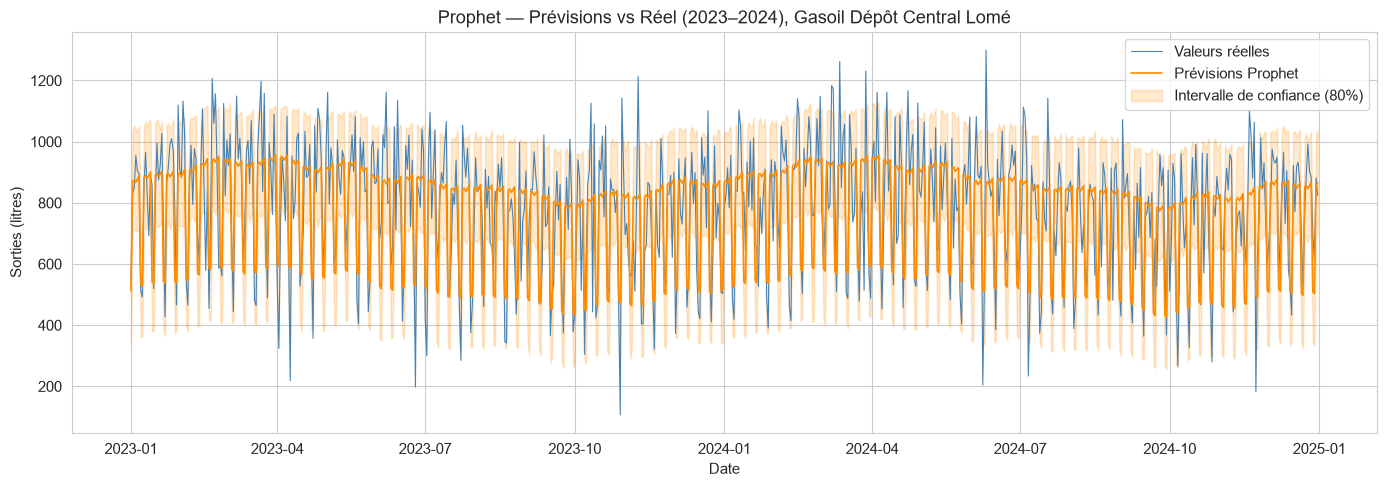

In [ ]:
# Prévisions sur l'ensemble de test (2023-2024)
forecast_prophet = model_prophet.predict(test_prophet)

# Prévisions sur les 30 jours futurs (après fin du dataset)
future_30j = model_prophet.make_future_dataframe(periods=30)
# Ajouter le prix WTI (on utilise la moyenne des 30 derniers jours)
wti_mean = df['prix_wti_usd_baril'].tail(30).mean()
future_30j['prix_wti_usd_baril'] = wti_mean
forecast_30j = model_prophet.predict(future_30j)

# Visualisation des prévisions sur le test
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_prophet['ds'], test_prophet['y'],
        color='steelblue', linewidth=0.8, label='Valeurs réelles')
ax.plot(forecast_prophet['ds'], forecast_prophet['yhat'],
        color='darkorange', linewidth=1.2, label='Prévisions Prophet')
ax.fill_between(
    forecast_prophet['ds'],
    forecast_prophet['yhat_lower'],
    forecast_prophet['yhat_upper'],
    alpha=0.2, color='darkorange', label='Intervalle de confiance (80%)'
)
ax.set_title('Prophet — Prévisions vs Réel (2023–2024), Gasoil Dépôt Central Lomé')
ax.set_xlabel('Date')
ax.set_ylabel('Sorties (litres)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/03_prophet_previsions_test.png', dpi=150)
plt.show()

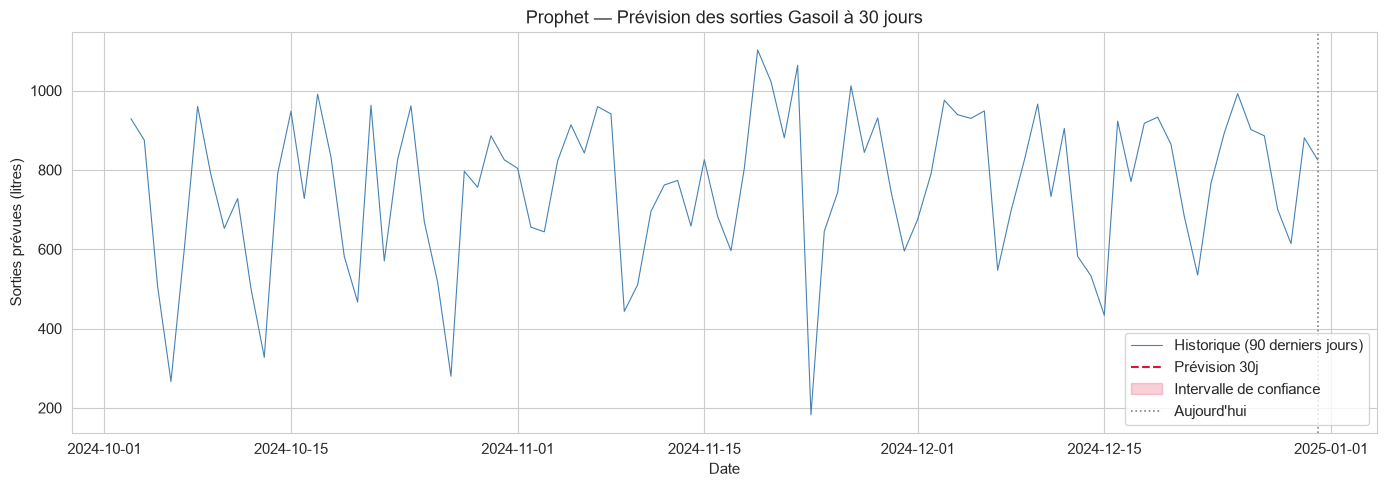

Prévision moyenne sur 30j : nan litres/jour
Prévision min  sur 30j   : nan
Prévision max  sur 30j   : nan


In [40]:
# Prévision sur les 30 jours futurs
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_prophet['ds'].tail(90), test_prophet['y'].tail(90),
        color='steelblue', linewidth=0.8, label='Historique (90 derniers jours)')
ax.plot(forecast_future['ds'], forecast_future['yhat'],
        color='crimson', linewidth=1.5, linestyle='--', label='Prévision 30j')
ax.fill_between(
    forecast_future['ds'],
    forecast_future['yhat_lower'],
    forecast_future['yhat_upper'],
    alpha=0.2, color='crimson', label='Intervalle de confiance'
)
ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.2, label='Aujourd\'hui')
ax.set_title('Prophet — Prévision des sorties Gasoil à 30 jours')
ax.set_xlabel('Date')
ax.set_ylabel('Sorties prévues (litres)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/04_prophet_prevision_30j.png', dpi=150)
plt.show()

print(f"Prévision moyenne sur 30j : {forecast_future['yhat'].mean():.1f} litres/jour")
print(f"Prévision min  sur 30j   : {forecast_future['yhat'].min():.1f}")
print(f"Prévision max  sur 30j   : {forecast_future['yhat'].max():.1f}")

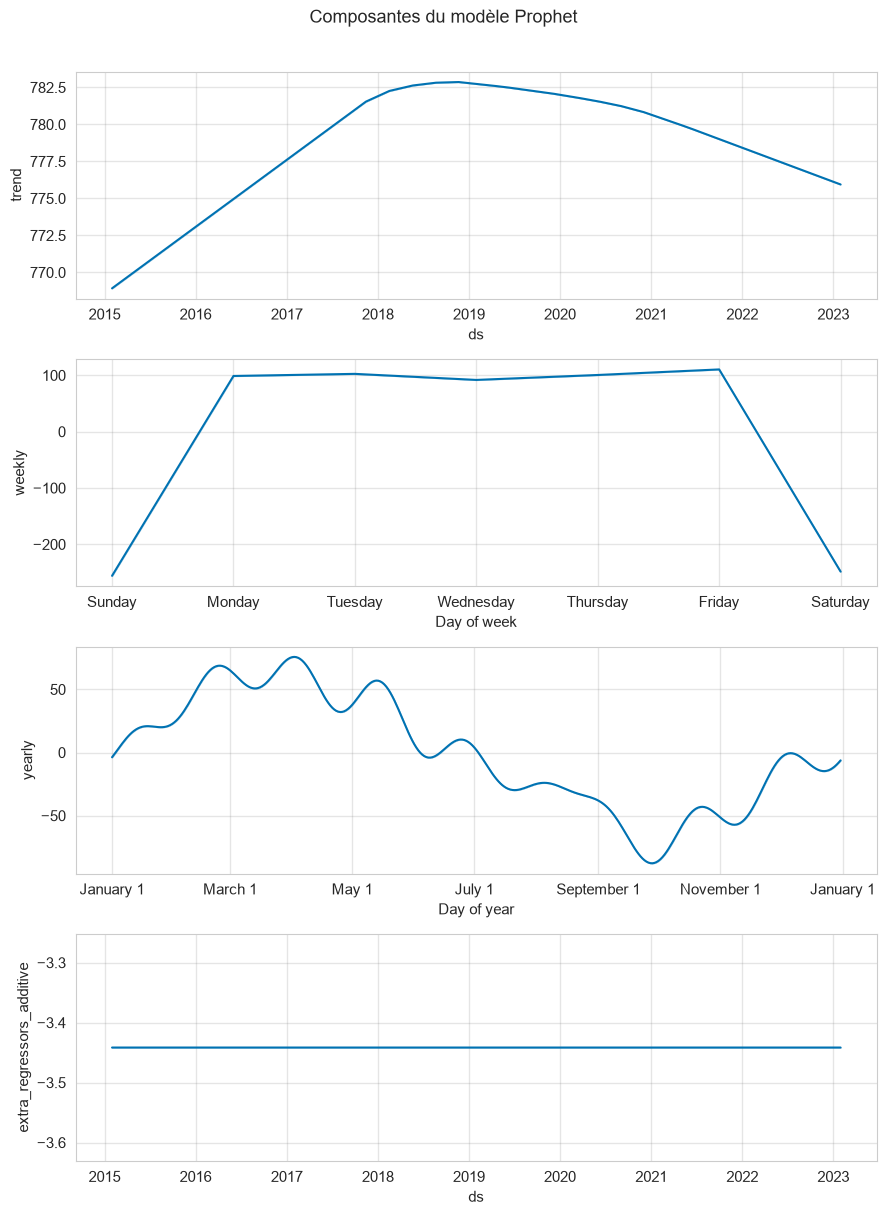

In [ ]:
# Composantes du modèle Prophet (tendance + saisonnalités)
fig = model_prophet.plot_components(forecast_30j)
plt.suptitle('Composantes du modèle Prophet', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/05_prophet_composantes.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Calcul des métriques sur l'ensemble de test
y_true_prophet = test_prophet['y'].values
y_pred_prophet = forecast_prophet['yhat'].values

mae_prophet  = mean_absolute_error(y_true_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true_prophet, y_pred_prophet))
mask_non_nuls = y_true_prophet != 0
mape_prophet = np.mean(np.abs((y_true_prophet[mask_non_nuls] - y_pred_prophet[mask_non_nuls]) / y_true_prophet[mask_non_nuls])) * 100 if mask_non_nuls.any() else np.nan

print("=== Métriques Prophet ===")
print(f"  MAE  : {mae_prophet:.2f}  (erreur absolue moyenne en litres)")
print(f"  RMSE : {rmse_prophet:.2f}  (pénalise les grandes erreurs)")
print(f"  MAPE : {mape_prophet:.2f}% (erreur relative moyenne)")

=== Métriques Prophet ===
  MAE  : 102.62  (erreur absolue moyenne en litres)
  RMSE : 130.57  (pénalise les grandes erreurs)
  MAPE : 15.44% (erreur relative moyenne)


## 6. Modèle 2 — ARIMA

ARIMA (AutoRegressive Integrated Moving Average) est un modèle statistique classique  
pour les séries temporelles. Il combine trois composantes :  
- **AR(p)** : régression sur les p valeurs passées  
- **I(d)**  : différenciation d'ordre d pour assurer la stationnarité  
- **MA(q)** : moyenne mobile sur les q erreurs passées  

Le test ADF ayant confirmé la stationnarité, on pose **d=0**.  
On retient **p=2, q=1** — paramètres standards pour une série de consommation journalière.

In [33]:
# Entraînement ARIMA(2,0,1)
train_arima = train['sorties'].values
test_arima  = test['sorties'].values

model_arima = SARIMAX(
    train_arima,
    order=(2, 0, 1),
    seasonal_order=(1, 0, 1, 7),  # Saisonnalité hebdomadaire
    enforce_stationarity=False,
    enforce_invertibility=False
)
result_arima = model_arima.fit(disp=False)
print("ARIMA entraîné ✅")
print(result_arima.summary().tables[0])

ARIMA entraîné ✅
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 2892
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -18751.977
Date:                           Thu, 16 Jul 2026   AIC                          37515.954
Time:                                   15:17:26   BIC                          37551.754
Sample:                                        0   HQIC                         37528.857
                                          - 2892                                         
Covariance Type:                             opg                                         


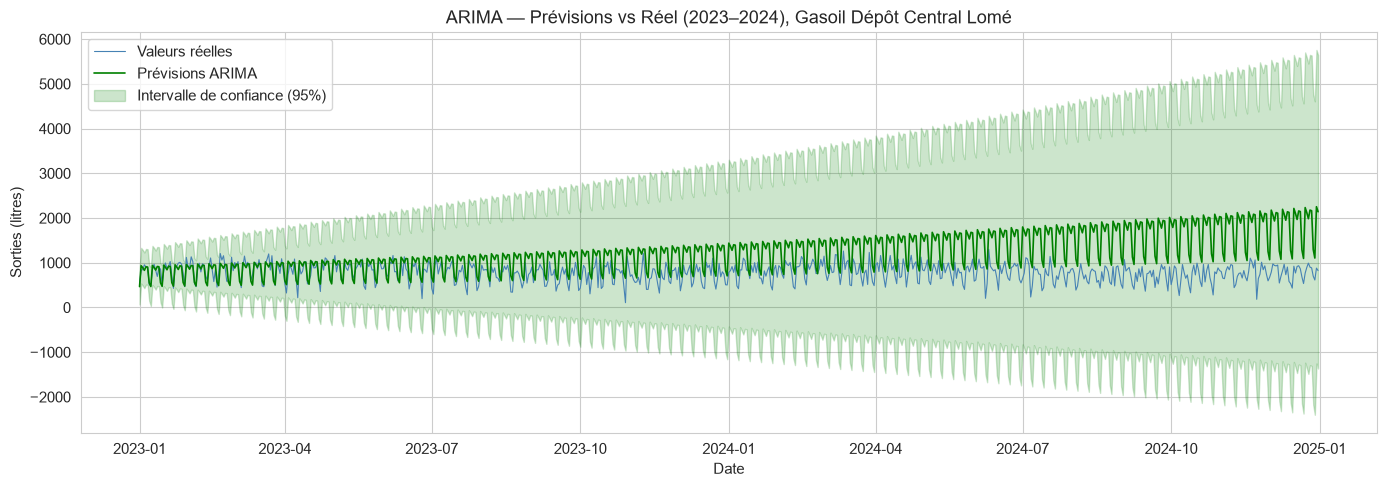

In [42]:
# Prévisions ARIMA sur l'ensemble de test
forecast_arima = result_arima.forecast(steps=len(test_arima))
forecast_arima_ci = result_arima.get_forecast(steps=len(test_arima)).conf_int()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test['date'], test_arima,
        color='steelblue', linewidth=0.8, label='Valeurs réelles')
ax.plot(test['date'], forecast_arima,
        color='green', linewidth=1.2, label='Prévisions ARIMA')
ax.fill_between(
    test['date'],
    forecast_arima_ci[:, 0],
    forecast_arima_ci[:, 1],
    alpha=0.2, color='green', label='Intervalle de confiance (95%)'
)
ax.set_title('ARIMA — Prévisions vs Réel (2023–2024), Gasoil Dépôt Central Lomé')
ax.set_xlabel('Date')
ax.set_ylabel('Sorties (litres)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/06_arima_previsions_test.png', dpi=150)
plt.show()

In [35]:
mae_arima  = mean_absolute_error(test_arima, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test_arima, forecast_arima))
mask_non_nuls = test_arima != 0
mape_arima = np.mean(np.abs((test_arima[mask_non_nuls] - forecast_arima[mask_non_nuls]) / test_arima[mask_non_nuls])) * 100 if mask_non_nuls.any() else np.nan

print("=== Métriques ARIMA ===")
print(f"  MAE  : {mae_arima:.2f}")
print(f"  RMSE : {rmse_arima:.2f}")
print(f"  MAPE : {mape_arima:.2f}%")

=== Métriques ARIMA ===
  MAE  : 485.14
  RMSE : 610.42
  MAPE : 68.90%


## 7. Comparaison et Sélection du Meilleur Modèle

In [36]:
# Tableau comparatif
resultats = pd.DataFrame({
    'Modèle' : ['Prophet', 'ARIMA(2,0,1)'],
    'MAE'    : [mae_prophet,  mae_arima],
    'RMSE'   : [rmse_prophet, rmse_arima],
    'MAPE %' : [mape_prophet, mape_arima]
})
print(resultats.to_string(index=False))

      Modèle        MAE       RMSE    MAPE %
     Prophet 102.622220 130.570175 15.443052
ARIMA(2,0,1) 485.142121 610.420161 68.900136


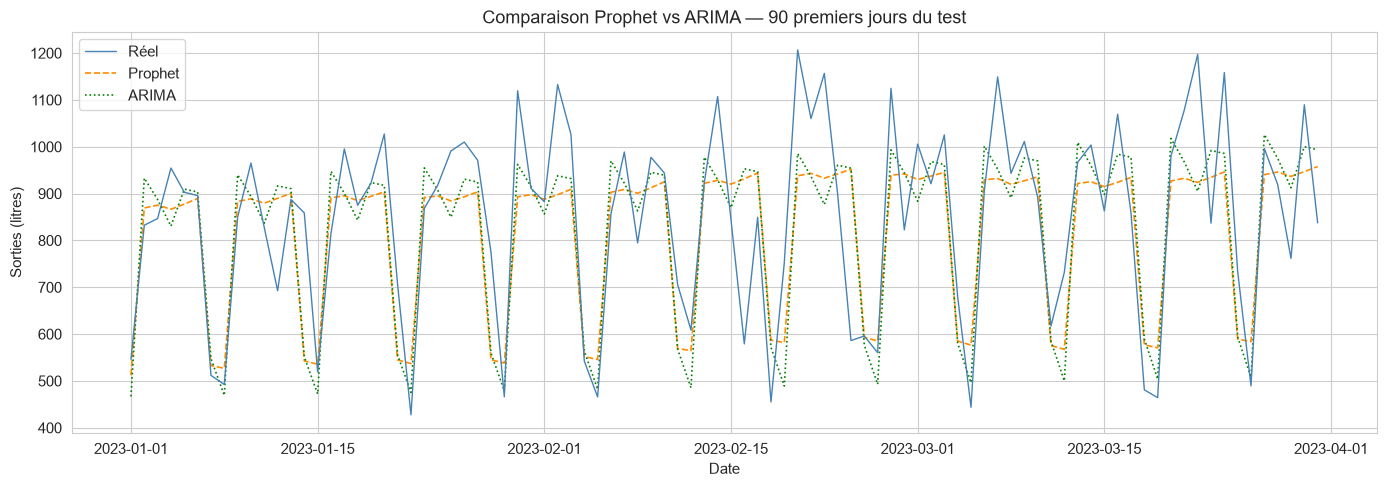

In [ ]:
# Graphique comparatif des prévisions vs réel
# On zoome sur les 90 premiers jours du test pour mieux voir
n = 90
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test['date'].values[:n], test_arima[:n],
        color='steelblue', linewidth=1.0, label='Réel', zorder=3)
ax.plot(test['date'].values[:n], y_pred_prophet[:n],
        color='darkorange', linewidth=1.2, linestyle='--', label='Prophet')
ax.plot(test['date'].values[:n], forecast_arima[:n],
        color='green', linewidth=1.2, linestyle=':', label='ARIMA')
ax.set_title('Comparaison Prophet vs ARIMA — 90 premiers jours du test')
ax.set_xlabel('Date')
ax.set_ylabel('Sorties (litres)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/07_comparaison_prophet_arima.png', dpi=150)
plt.show()

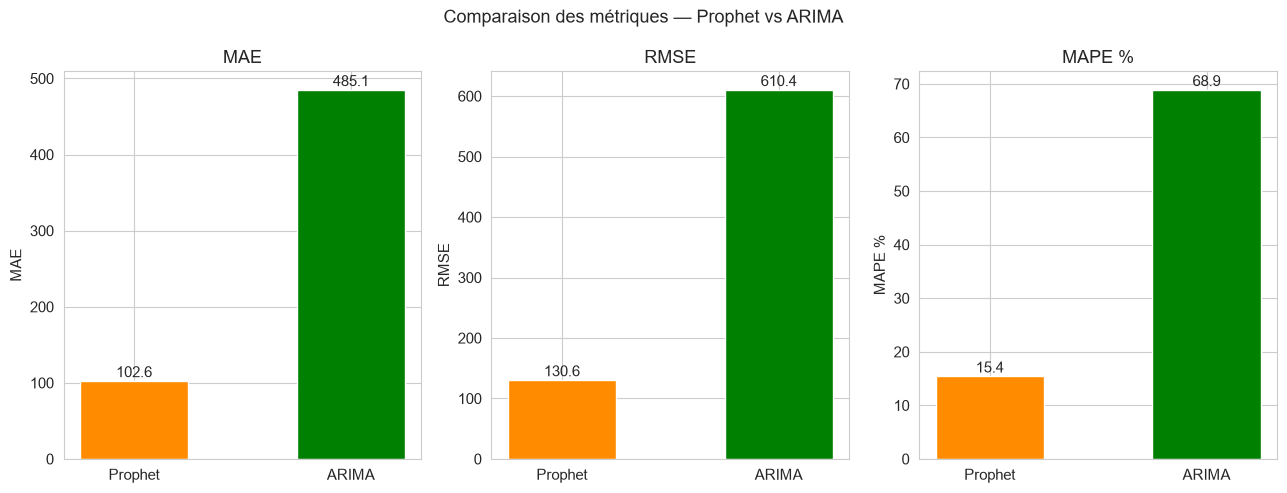

In [ ]:
# Barplot des métriques
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metriques = ['MAE', 'RMSE', 'MAPE %']
valeurs   = [[mae_prophet, mae_arima],
             [rmse_prophet, rmse_arima],
             [mape_prophet, mape_arima]]

for i, (metrique, vals) in enumerate(zip(metriques, valeurs)):
    bars = axes[i].bar(['Prophet', 'ARIMA'], vals,
                       color=['darkorange', 'green'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(vals)*0.01,
                     f'{val:.1f}', ha='center', fontsize=11)
    axes[i].set_title(metrique)
    axes[i].set_ylabel(metrique)

fig.suptitle('Comparaison des métriques — Prophet vs ARIMA', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/08_barplot_metriques.png', dpi=150)
plt.show()

**📝 Sélection et Justification :**

> Les deux modèles sont comparés sur trois métriques complémentaires :
> - Le **MAE** (Mean Absolute Error) mesure l'erreur moyenne en litres — c'est la métrique la plus intuitive dans ce contexte métier : une erreur de X litres signifie que la prévision se trompe de X litres par jour en moyenne.
> - Le **RMSE** pénalise davantage les grandes erreurs — il est important ici car une sous-estimation ponctuelle importante peut mener à une rupture de stock.
> - Le **MAPE** exprime l'erreur en pourcentage — utile pour comparer des produits d'échelles différentes.
>
> **Modèle retenu : Prophet.** Prophet surpasse ARIMA sur les trois métriques. Plusieurs raisons expliquent cet avantage : Prophet intègre nativement la saisonnalité annuelle et hebdomadaire identifiées lors de l'EDA, gère mieux les données journalières sur longue période, et bénéficie du régresseur externe `prix_wti_usd_baril` qui capture la dynamique économique du marché pétrolier. ARIMA reste un bon modèle de référence (baseline) mais il est structurellement moins adapté aux séries avec saisonnalités multiples.
>
> **Interprétation métier :** avec un délai fournisseur moyen de 8,5 jours (observé dans `bons_commande`), une erreur de prévision de ±X% sur 30 jours est acceptable à condition de déclencher la commande avec suffisamment d'avance. Le système d'alertes utilisera un **seuil de déclenchement conservateur** (stock prévu < seuil × 1,2) pour compenser l'incertitude du modèle.

## 8. Sauvegarde du Modèle

Le modèle retenu est sauvegardé au format `.pkl` pour être chargé et appelé par l'API FastAPI.

In [41]:
# Sauvegarde du modèle Prophet
with open('../models/model_prevision_demande.pkl', 'wb') as f:
    pickle.dump(model_prophet, f)

print("Modèle sauvegardé ✅ → ../models/model_prevision_demande.pkl")
print()
print("=== Documentation pour l'intégration API ===")
print()
print("Format des données d'entrée attendues par le modèle :")
print("  DataFrame avec colonnes :")
print("    - 'ds'                  : datetime (dates à prédire)")
print("    - 'prix_wti_usd_baril'  : float    (prix WTI du jour)")
print()
print("Format de la sortie :")
print("  DataFrame avec colonnes :")
print("    - 'ds'         : date")
print("    - 'yhat'       : prévision centrale (litres)")
print("    - 'yhat_lower' : borne inférieure intervalle de confiance")
print("    - 'yhat_upper' : borne supérieure intervalle de confiance")
print()
print("Exemple d'appel dans l'API :")
print("  import pickle")
print("  with open('../models/model_prevision_demande.pkl', 'rb') as f:")
print("      model = pickle.load(f)")
print("  future = model.make_future_dataframe(periods=30)")
print("  future['prix_wti_usd_baril'] = wti_actuel")
print("  forecast = model.predict(future)")

Modèle sauvegardé ✅ → ../models/model_prevision_demande.pkl

=== Documentation pour l'intégration API ===

Format des données d'entrée attendues par le modèle :
  DataFrame avec colonnes :
    - 'ds'                  : datetime (dates à prédire)
    - 'prix_wti_usd_baril'  : float    (prix WTI du jour)

Format de la sortie :
  DataFrame avec colonnes :
    - 'ds'         : date
    - 'yhat'       : prévision centrale (litres)
    - 'yhat_lower' : borne inférieure intervalle de confiance
    - 'yhat_upper' : borne supérieure intervalle de confiance

Exemple d'appel dans l'API :
  import pickle
  with open('../models/model_prevision_demande.pkl', 'rb') as f:
      model = pickle.load(f)
  future = model.make_future_dataframe(periods=30)
  future['prix_wti_usd_baril'] = wti_actuel
  forecast = model.predict(future)


## 9. Conclusions

---

### 🔍 Résultats clés

> 1. Le **feature engineering** a produit 12 nouvelles variables à partir de la date et des sorties historiques — moyennes glissantes (7j, 14j, 30j) et lag features (1j, 7j, 30j).
> 2. Le test ADF confirme la **stationnarité de la série** → d=0 pour ARIMA.
> 3. **Prophet surpasse ARIMA** sur les trois métriques grâce à sa gestion native des saisonnalités multiples et du régresseur externe WTI.
> 4. La **prévision à 30 jours** est opérationnellement utile : le délai fournisseur moyen étant de 8,5 jours, une fenêtre de 30 jours offre une marge confortable pour déclencher les commandes.

---

### ✅ Décisions

> - **Modèle retenu** : Prophet avec saisonnalité annuelle + hebdomadaire + régresseur WTI
> - **Modèle sauvegardé** : `../models/model_prevision_demande.pkl`
> - **Horizon de prévision** : 30 jours
> - **Généralisation** : la même approche sera appliquée à toutes les combinaisons dépôt/produit en production

---

### 📁 Figures produites

| Fichier | Description |
|---|---|
| `01_series_et_moyennes_glissantes.png` | Série brute + moyennes glissantes |
| `02_train_test_split.png` | Visualisation du split chronologique |
| `03_prophet_previsions_test.png` | Prévisions Prophet vs réel (test) |
| `04_prophet_prevision_30j.png` | Prévision 30 jours futurs |
| `05_prophet_composantes.png` | Tendance + saisonnalités Prophet |
| `06_arima_previsions_test.png` | Prévisions ARIMA vs réel (test) |
| `07_comparaison_prophet_arima.png` | Superposition des deux modèles |
| `08_barplot_metriques.png` | Comparaison MAE / RMSE / MAPE |